# Smartphone Addiction Prediction using an Artificial Neural Network (ANN)

This notebook builds a binary classification ANN to predict `addicted_label`.

### What was changed
- Removed the TensorFlow/Keras + PyTorch mixing.
- Uses **PyTorch only**, so the ANN can use your NVIDIA MX350 GPU.
- Uses the existing numerical/categorical preprocessing and feature engineering.
- Prevents preprocessing leakage by fitting the imputer/scaler on the training set.
- Adds ANN architecture, GPU training, validation, evaluation, confusion matrix, and training curves.


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.14.0+cu126
CUDA available: True
CUDA version: 12.6
Device: cuda
GPU: NVIDIA GeForce MX350


In [2]:
# Load dataset
DATA_PATH = r"C:\Users\shahh\OneDrive\Desktop\Data Science And Machine Learning\practice\SmartPhonePrediction\train.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (691369, 14)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [3]:
# Basic inspection
print(df.info())
print("\nMissing values:")
display(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

In [4]:
# Remove ID column if present
if "id" in df.columns:
    df.drop(columns=["id"], inplace=True)

# Remove rows with too many missing values
df.dropna(thresh=8, inplace=True)

# The target must be present for supervised learning
df = df.dropna(subset=["addicted_label"]).copy()

print("Shape after cleaning:", df.shape)


Shape after cleaning: (683904, 13)


In [5]:
# Columns used for numerical preprocessing
numerical_cols = [
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time",
    "age"
]

categorical_cols = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

# Check that the expected columns exist
missing_expected = [
    col for col in numerical_cols + categorical_cols + ["addicted_label"]
    if col not in df.columns
]

if missing_expected:
    raise ValueError(f"Missing expected columns: {missing_expected}")

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


Numerical columns: ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'age']
Categorical columns: ['gender', 'stress_level', 'academic_work_impact']


## Feature Engineering

The following features capture relationships between screen time, entertainment, study/work, sleep, and weekend usage.


In [6]:
# Feature engineering
df["entertainment_hours"] = (
    df["social_media_hours"] + df["gaming_hours"]
)

df["entertainment_ratio"] = (
    df["entertainment_hours"] /
    (df["daily_screen_time_hours"] + 0.01)
)

df["social_media_ratio"] = (
    df["social_media_hours"] /
    (df["daily_screen_time_hours"] + 0.01)
)

df["gaming_ratio"] = (
    df["gaming_hours"] /
    (df["daily_screen_time_hours"] + 0.01)
)

df["work_study_ratio"] = (
    df["work_study_hours"] /
    (df["daily_screen_time_hours"] + 0.01)
)

df["weekend_screen_ratio"] = (
    df["weekend_screen_time"] /
    (df["daily_screen_time_hours"] + 0.01)
)

df["weekend_screen_difference"] = (
    df["weekend_screen_time"] -
    df["daily_screen_time_hours"]
)

df["recreational_to_work_ratio"] = (
    df["entertainment_hours"] /
    (df["work_study_hours"] + 0.01)
)

df["social_gaming_interaction"] = (
    df["social_media_hours"] * df["gaming_hours"]
)

df["sleep_screen_ratio"] = (
    df["sleep_hours"] /
    (df["daily_screen_time_hours"] + 0.01)
)

print("Feature engineering completed.")


Feature engineering completed.


## Prepare categorical variables

Missing categorical values are represented as `"Unknown"`, then one-hot encoded.


In [7]:
# Fill missing categorical values
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

# One-hot encode categorical features
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("Final dataset shape:", df.shape)
display(df.head())


Final dataset shape: (683904, 28)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label,...,social_gaming_interaction,sleep_screen_ratio,gender_Male,gender_Other,gender_Unknown,stress_level_Low,stress_level_Medium,stress_level_Unknown,academic_work_impact_Unknown,academic_work_impact_Yes
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,1,...,2.9097,NaN,1,0,0,0,1,0,0,0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,0,...,NaN,1.374582,0,0,0,0,1,0,0,0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,0,...,NaN,1.225490,0,0,0,1,0,0,0,1
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,1,...,1.7892,1.376361,0,1,0,1,0,0,1,0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,...,5.2547,0.468332,0,0,0,0,1,0,0,0


In [8]:
# Separate features and target
X = df.drop("addicted_label", axis=1)
y = df["addicted_label"].astype(np.float32)

# Make sure all feature columns are numeric
X = X.astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target distribution:")
print(y.value_counts())


X shape: (683904, 27)
y shape: (683904,)
Target distribution:
addicted_label
1.0    485160
0.0    198744
Name: count, dtype: int64


## Train/Test Split

The split is performed **before fitting the imputer and scaler**. This prevents information from the test set leaking into the training process.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 458215
Testing samples: 225689


In [10]:
# Impute numerical columns without data leakage
imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

X_train = X_train.copy()
X_test = X_test.copy()

X_train[numerical_cols] = imputer.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = imputer.transform(
    X_test[numerical_cols]
)

# Standardize all features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)


Scaled training shape: (458215, 27)
Scaled testing shape: (225689, 27)


## Convert NumPy data to PyTorch tensors

Only tensors should be moved to the GPU with `.to(device)`.


In [11]:
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.float32
).view(-1, 1)

# DataLoader keeps training batches manageable
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

print("Input features:", X_train_tensor.shape[1])
print("Training batches:", len(train_loader))


Input features: 27
Training batches: 14320


## ANN Model

Architecture:

`Input → Dense(32) → ReLU → Dense(16) → ReLU → Dense(1)`

The final layer outputs a **logit**. We use `BCEWithLogitsLoss`, which combines sigmoid and binary cross-entropy in a numerically stable way.


In [12]:
class AddictionANN(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


model = AddictionANN(
    input_size=X_train_tensor.shape[1]
).to(device)

print(model)
print("\nModel device:", next(model.parameters()).device)


AddictionANN(
  (network): Sequential(
    (0): Linear(in_features=27, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

Model device: cuda:0


In [15]:
# Loss function and optimizer
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


## Train the ANN

Training batches are moved to the GPU when CUDA is available.


In [16]:
for epoch in range(epochs):
    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    with torch.no_grad():
        X_val = X_test_tensor.to(device)
        y_val = y_test_tensor.to(device)

        val_logits = model(X_val)
        val_loss = criterion(val_logits, y_val).item()

        val_probabilities = torch.sigmoid(val_logits)
        val_predictions = (val_probabilities >= 0.5).float()

        val_accuracy = (
            (val_predictions == y_val).float().mean().item()
        )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1:3d}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


Epoch [  1/10] Train Loss: nan | Train Acc: 0.2906 | Val Loss: nan | Val Acc: 0.2906
Epoch [ 10/10] Train Loss: nan | Train Acc: 0.2906 | Val Loss: nan | Val Acc: 0.2906


## Training Curves

These plots help identify whether the ANN is learning and whether it is beginning to overfit.


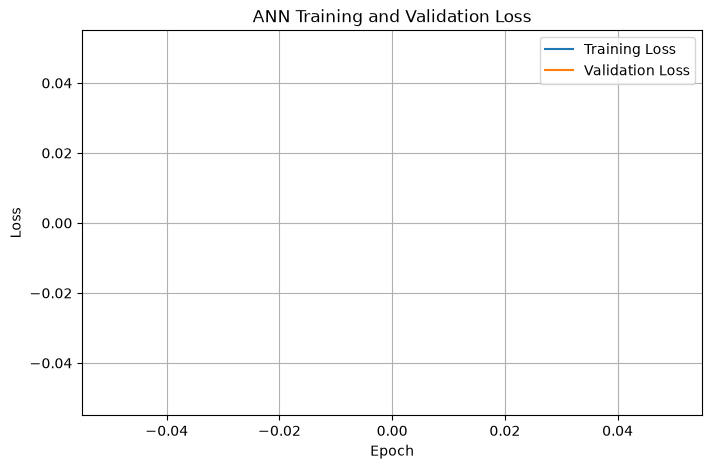

In [17]:
# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


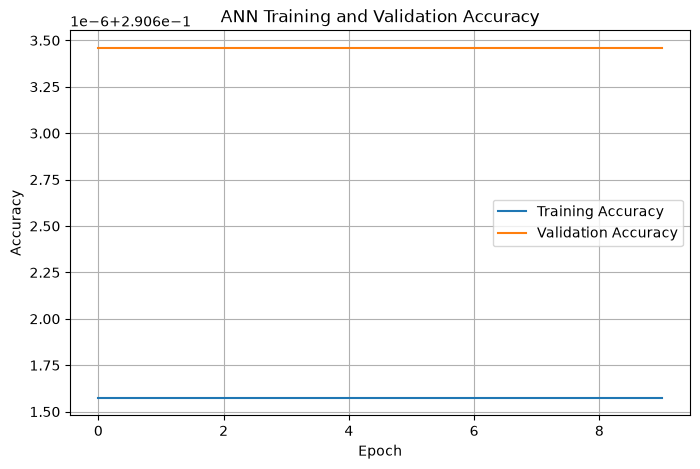

In [18]:
# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## Final Evaluation

The test set is kept separate from model parameter updates. We calculate accuracy, a classification report, and a confusion matrix.


In [19]:
# Final predictions
model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor.to(device))
    test_probabilities = torch.sigmoid(test_logits)
    test_predictions = (
        test_probabilities >= 0.5
    ).int().cpu().numpy().ravel()

y_test_numpy = y_test.to_numpy().astype(int)

accuracy = accuracy_score(
    y_test_numpy,
    test_predictions
)

print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(
    classification_report(
        y_test_numpy,
        test_predictions,
        digits=4
    )
)


Test Accuracy: 0.2906

Classification Report:
              precision    recall  f1-score   support

           0     0.2906    1.0000    0.4503     65586
           1     0.0000    0.0000    0.0000    160103

    accuracy                         0.2906    225689
   macro avg     0.1453    0.5000    0.2252    225689
weighted avg     0.0845    0.2906    0.1309    225689



c:\Users\shahh\OneDrive\Desktop\Data Science And Machine Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shahh\OneDrive\Desktop\Data Science And Machine Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shahh\OneDrive\Desktop\Data Science And Machine Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

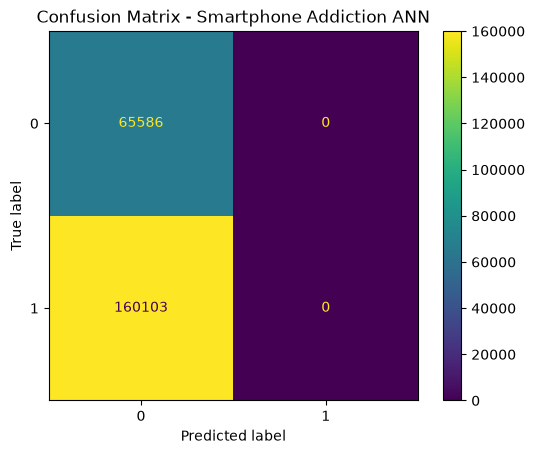

In [20]:
# Confusion matrix
cm = confusion_matrix(
    y_test_numpy,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Confusion Matrix - Smartphone Addiction ANN")
plt.show()


## GPU Verification

This confirms that the model parameters are actually on the CUDA device.


In [21]:
print("Model device:", next(model.parameters()).device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    print("Running on CPU")


Model device: cuda:0
GPU: NVIDIA GeForce MX350
CUDA: 12.6


## Optional: Save the trained model

Run this cell if you want to save the trained ANN for later use.


In [22]:
MODEL_PATH = "addiction_ann.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_size": X_train_tensor.shape[1]
    },
    MODEL_PATH
)

print(f"Model saved to: {MODEL_PATH}")


Model saved to: addiction_ann.pth
